# Notebook 4 — Exploratory Data Analysis

## Goal

Explore the training data in detail to understand data quality, distributions, categories, relationships, dates, and possible features.

Only the training split from the random stratified split is used in this notebook.

The findings will help us decide which features and preprocessing steps to use in Notebook 5.

In [1]:
%pip install  holidays

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

## 1. Load the training artifact

Notebook 3 created the random stratified split.

We load only the training data because the test set must remain untouched during EDA.

In [3]:
train = pd.read_csv(
    "../artifacts/random_split/train1.csv"
)

print("Shape:", train.shape)
train.head()

Shape: (67529, 28)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,number_of_product_categories,customer_seller_distance_km,customer_seller_same_state,number_of_payments,total_payment,average_installments,max_installments,main_payment_type,delivery_delay_days,late_delivery
0,469486849094bf1935cd99d96e117ded,4823c52e962bd334cf992817bcdff533,delivered,2017-08-23 19:47:18,2017-08-23 20:06:55,2017-08-24 15:27:12,2017-09-01 15:51:37,2017-09-15,d7f36ed554c844d47a19567041894aa3,22270,...,1.0,353.378574,False,1.0,63.61,3.0,3.0,credit_card,-13.339155,0
1,a03f26d6437188462f6e42f098b7e7c0,40897a63d388c1d1f1844f334d404d5f,delivered,2017-12-06 20:38:11,2017-12-07 03:10:50,2017-12-07 18:39:09,2017-12-18 15:44:01,2018-01-09,24bb54e643e350ee42ff34b6bfb66e4b,37900,...,1.0,731.258180,False,1.0,55.29,1.0,1.0,boleto,-21.344433,0
2,b47238f009b4f97b2676067d6c0c0386,d848c524b1e0639c9bfde8852bd810e4,delivered,2018-08-14 09:58:07,2018-08-14 10:10:15,2018-08-14 14:39:00,2018-08-16 20:52:02,2018-08-21,c4e1be2c2425a037aebd1443b7c59bbd,8485,...,1.0,43.545261,True,1.0,58.45,1.0,1.0,credit_card,-4.130532,0
3,ee789d8c9f580179177f5445b0e92a1f,b53d492bd12be0c61763877147a919ed,delivered,2018-04-29 21:03:17,2018-04-29 21:15:15,2018-04-30 15:09:00,2018-05-03 18:55:25,2018-05-14,99abce227f20bc33f1e1b601b2b03ea4,4950,...,1.0,6.635732,True,1.0,119.12,2.0,2.0,credit_card,-10.211516,0
4,d27d803d3a838c539ffe76e3b74a5f41,75f4c47dc2249c41ece095b0022f6be6,delivered,2018-03-06 01:39:41,2018-03-06 01:50:26,2018-03-07 00:51:26,2018-03-14 20:03:06,2018-03-23,b24a663744af5fb1f84368bdcb311f4e,50810,...,1.0,1198.671670,False,1.0,82.47,3.0,3.0,credit_card,-8.164514,0


In [4]:
print("Columns:")
print(train.columns.tolist())

print("\nData types:")
print(train.dtypes)

memory_usage = train.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"\nMemory usage: {memory_usage:.2f} MB")

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'number_of_items', 'number_of_sellers', 'total_price', 'total_freight', 'total_product_weight', 'total_product_volume', 'number_of_product_categories', 'customer_seller_distance_km', 'customer_seller_same_state', 'number_of_payments', 'total_payment', 'average_installments', 'max_installments', 'main_payment_type', 'delivery_delay_days', 'late_delivery']

Data types:
order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
customer_unique_i

## 2. Classify the Columns

We separate IDs, the target, dates, numerical variables,
categorical variables, and variables that contain future information.

This makes the later EDA and feature decisions easier to follow.

In [5]:
id_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

target_column = "late_delivery"

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

future_columns = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "delivery_delay_days"
]

print("ID columns:", id_columns)
print("\nTarget:", target_column)
print("\nDate columns:", date_columns)
print("\nFuture-information columns:", future_columns)

ID columns: ['order_id', 'customer_id', 'customer_unique_id']

Target: late_delivery

Date columns: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Future-information columns: ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'delivery_delay_days']


## 3. Convert Date Columns

The date columns are stored as text in the CSV file.

We convert them to datetime so they can be analyzed correctly.

In [6]:
for column in date_columns:
    train[column] = pd.to_datetime(
        train[column],
        errors="coerce"
    )

train[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

## 4. Check Missing Values

We check how many values are missing in each column.

Missing values are not automatically filled or removed in this notebook.
The preprocessing decision will be made later.

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percentage": train.isna().mean() * 100
}).sort_values(
    "missing_percentage",
    ascending=False
)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percentage
customer_seller_distance_km,328,0.485717
order_approved_at,11,0.016289


## 5. Numerical Features

We examine the numerical order-level variables, including item,
price, freight, payment, product, and geographic features.

The ZIP-code prefix is treated separately because it represents
a geographic identifier rather than a continuous measurement.

In [8]:
numerical_features = [
    "number_of_items",
    "number_of_sellers",
    "total_price",
    "total_freight",
    "total_product_weight",
    "total_product_volume",
    "number_of_product_categories",
    "customer_seller_distance_km",
    "number_of_payments",
    "total_payment",
    "average_installments",
    "max_installments"
]

numerical_summary = train[numerical_features].describe().T

numerical_summary["skewness"] = (
    train[numerical_features].skew()
)

numerical_summary[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness"
    ]
]

,count,mean,std,min,25%,50%,75%,max,skewness
number_of_items,67529.0,1.140384,0.530231,1.00,1.000000,1.000000,1.000000,2.000000e+01,6.910788
number_of_sellers,67529.0,1.013846,0.122784,1.00,1.000000,1.000000,1.000000,5.000000e+00,9.780457
total_price,67529.0,137.785073,210.958550,0.85,45.950000,86.900000,149.900000,1.344000e+04,10.236822
total_freight,67529.0,22.802874,22.242157,0.00,13.850000,17.160000,24.050000,1.794960e+03,14.349653
total_product_weight,67529.0,2382.793703,4763.559460,0.00,300.000000,750.000000,2050.000000,1.542000e+05,6.462348
total_product_volume,67529.0,17291.407351,30109.649600,0.00,2964.000000,7200.000000,19825.000000,1.476000e+06,7.592105
number_of_product_categories,67529.0,0.993692,0.147206,0.00,1.000000,1.000000,1.000000,3.000000e+00,-1.681918
customer_seller_distance_km,67201.0,601.572622,593.628495,0.00,190.096649,435.409017,799.149945,8.677912e+03,1.698217
number_of_payments,67529.0,1.044662,0.357517,1.00,1.000000,1.000000,1.000000,2.200000e+01,19.434396
total_payment,67529.0,160.619072,220.921423,9.59,62.020000,105.350000,176.750000,1.366408e+04,9.681093


## 6. Numerical Distributions

Histograms are used to check the shape of the numerical variables,
including skewness and extreme values.

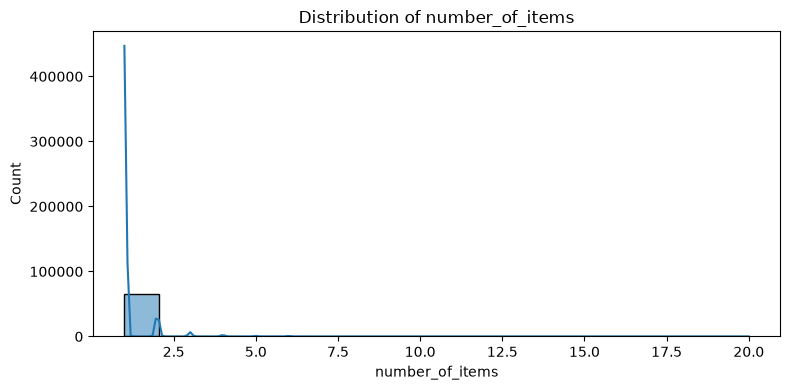

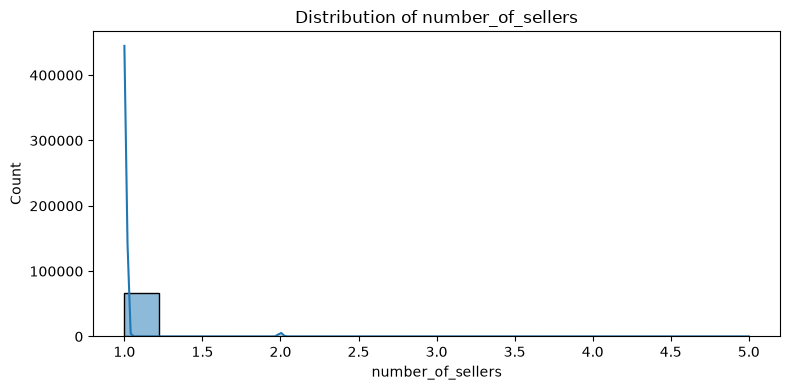

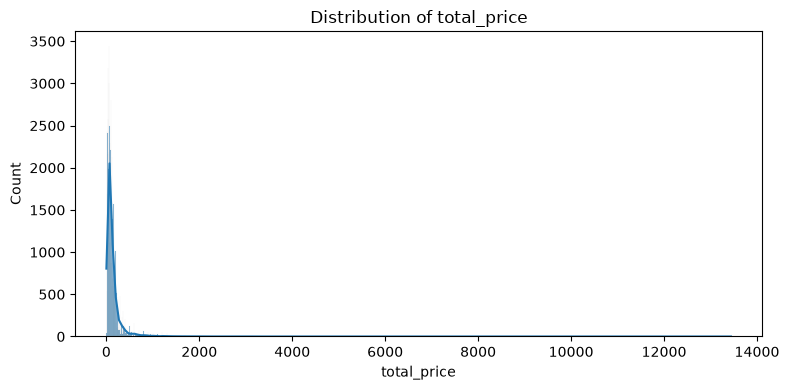

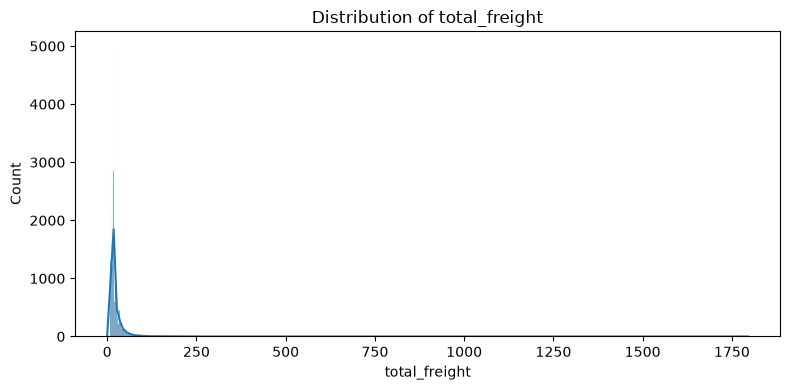

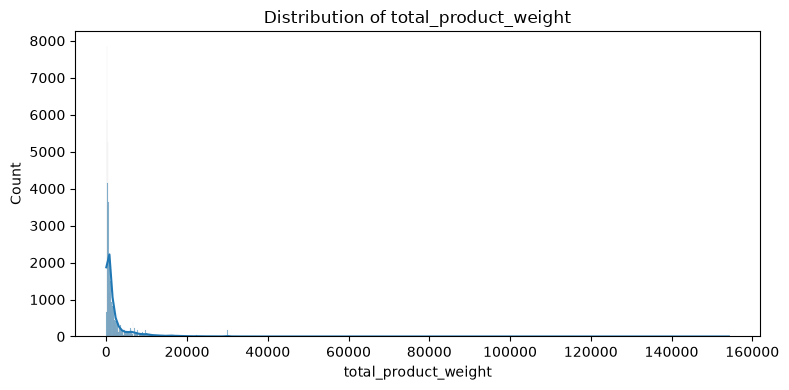

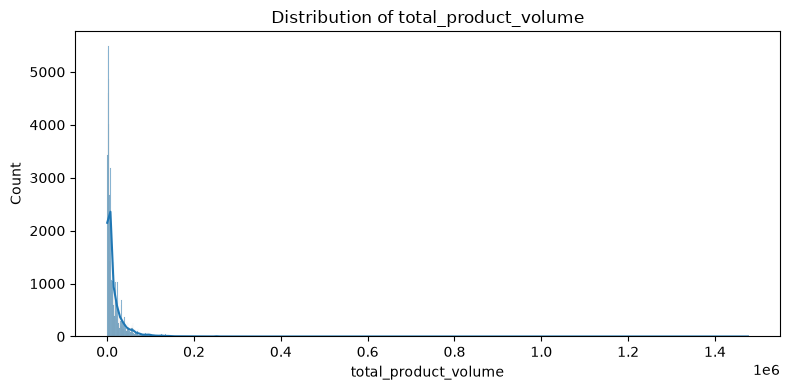

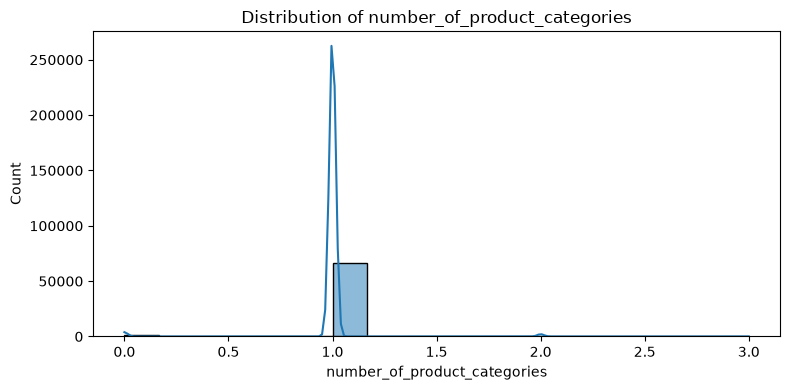

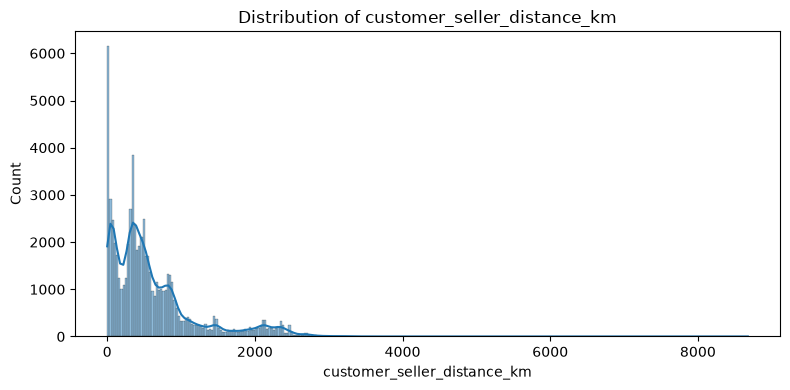

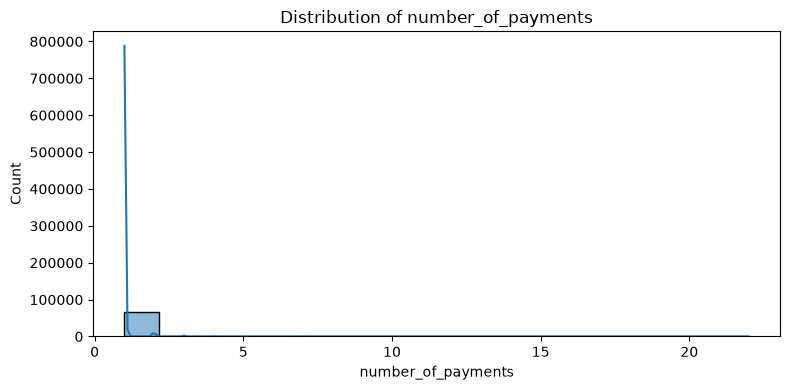

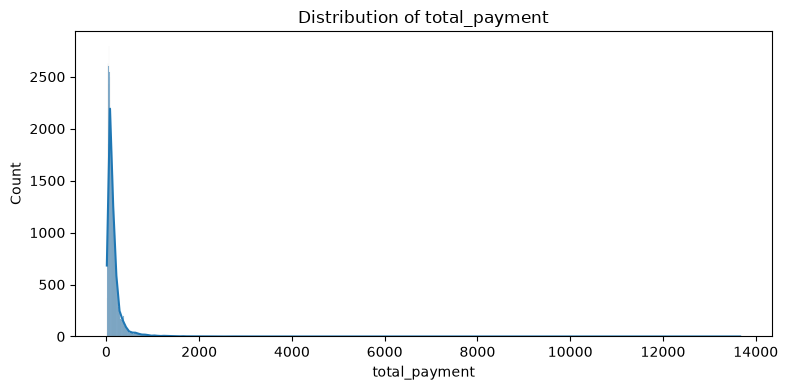

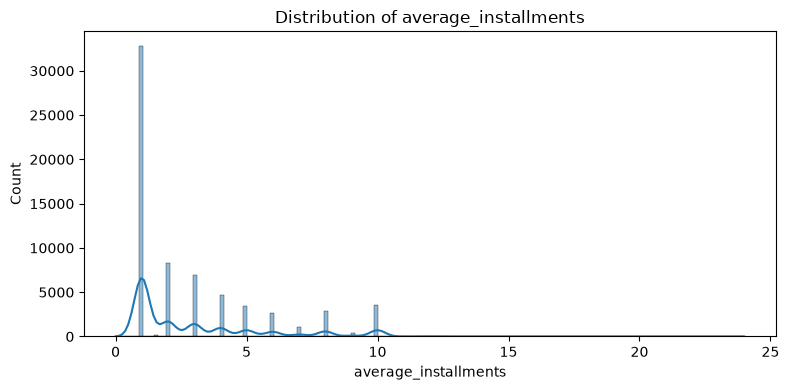

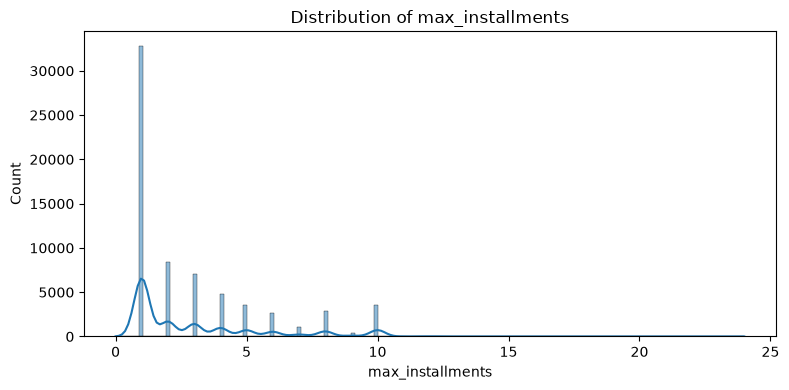

In [9]:
os.makedirs(
    "../artifacts/random_split/eda1",
    exist_ok=True
)

for column in numerical_features:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=train,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.tight_layout()

    plt.savefig(
        f"../artifacts/random_split/eda1/distribution_{column}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

## 7. Check Potential Outliers

The IQR method is used to identify potential outliers.

A value flagged as an outlier is not automatically considered wrong.
Large orders, prices, weights, or distances can be valid observations.

In [10]:
outlier_results = []

for column in numerical_features:
    q1 = train[column].quantile(0.25)
    q3 = train[column].quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        outlier_count = (
            train[column] != q1
        ).sum()

        lower_bound = q1
        upper_bound = q3
    else:
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_count = (
            (train[column] < lower_bound)
            |
            (train[column] > upper_bound)
        ).sum()

    outlier_results.append({
        "feature": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": (
            outlier_count / len(train) * 100
        )
    })

outlier_summary = pd.DataFrame(
    outlier_results
)

outlier_summary

,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
0,number_of_items,1.000000,1.000000,6660,9.862429
1,number_of_sellers,1.000000,1.000000,893,1.322395
2,total_price,-109.975000,305.825000,5454,8.076530
3,total_freight,-1.450000,39.350000,6719,9.949799
4,total_product_weight,-2325.000000,4675.000000,9459,14.007315
5,total_product_volume,-22327.500000,45116.500000,6240,9.240474
6,number_of_product_categories,1.000000,1.000000,1448,2.144264
7,customer_seller_distance_km,-723.483295,1712.729889,5235,7.752225
8,number_of_payments,1.000000,1.000000,2050,3.035733
9,total_payment,-110.075000,348.845000,5379,7.965467


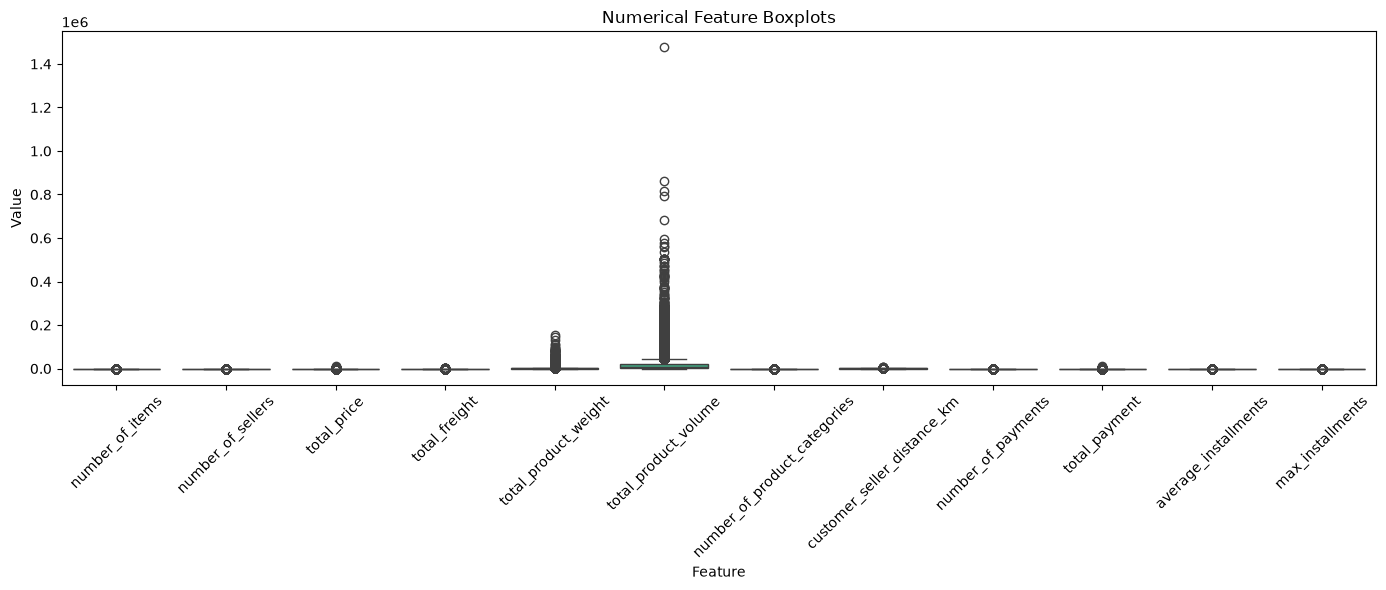

In [11]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=train[numerical_features]
)

plt.title("Numerical Feature Boxplots")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/numerical_boxplots.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 8. Numerical Features vs Target

We compare the average value of each numerical feature between
on-time and late orders.

This gives an initial indication of whether a feature may contain
useful information about late delivery.

In [12]:
numeric_vs_label = (
    train.groupby("late_delivery")[numerical_features]
    .mean()
    .T
)

numeric_vs_label.columns = [
    "On-time (0)",
    "Late (1)"
]

numeric_vs_label["Difference"] = (
    numeric_vs_label["Late (1)"]
    - numeric_vs_label["On-time (0)"]
)

numeric_vs_label

,On-time (0),Late (1),Difference
number_of_items,1.143414,1.106061,-0.037354
number_of_sellers,1.014875,1.002191,-0.012684
total_price,136.797736,148.968943,12.171207
total_freight,22.652054,24.511254,1.859200
total_product_weight,2359.146863,2650.648777,291.501914
total_product_volume,17205.276837,18267.034319,1061.757482
number_of_product_categories,0.994311,0.986674,-0.007637
customer_seller_distance_km,588.878473,745.633255,156.754782
number_of_payments,1.045076,1.039978,-0.005098
total_payment,159.481791,173.501409,14.019618


## 9. Correlation with the Target

We check the correlation between numerical variables and the target.

Correlation only measures a linear relationship, so a weak correlation
does not automatically mean that a feature is useless.

In [13]:
correlations = (
    train[
        numerical_features + [target_column]
    ]
    .corr()[target_column]
    .drop(target_column)
    .sort_values(
        key=abs,
        ascending=False
    )
)

correlations

customer_seller_distance_km     0.072038
number_of_sellers              -0.028205
total_freight                   0.022822
number_of_items                -0.019234
total_payment                   0.017326
total_product_weight            0.016707
total_price                     0.015752
number_of_product_categories   -0.014165
total_product_volume            0.009628
average_installments            0.007123
max_installments                0.007100
number_of_payments             -0.003893
Name: late_delivery, dtype: float64

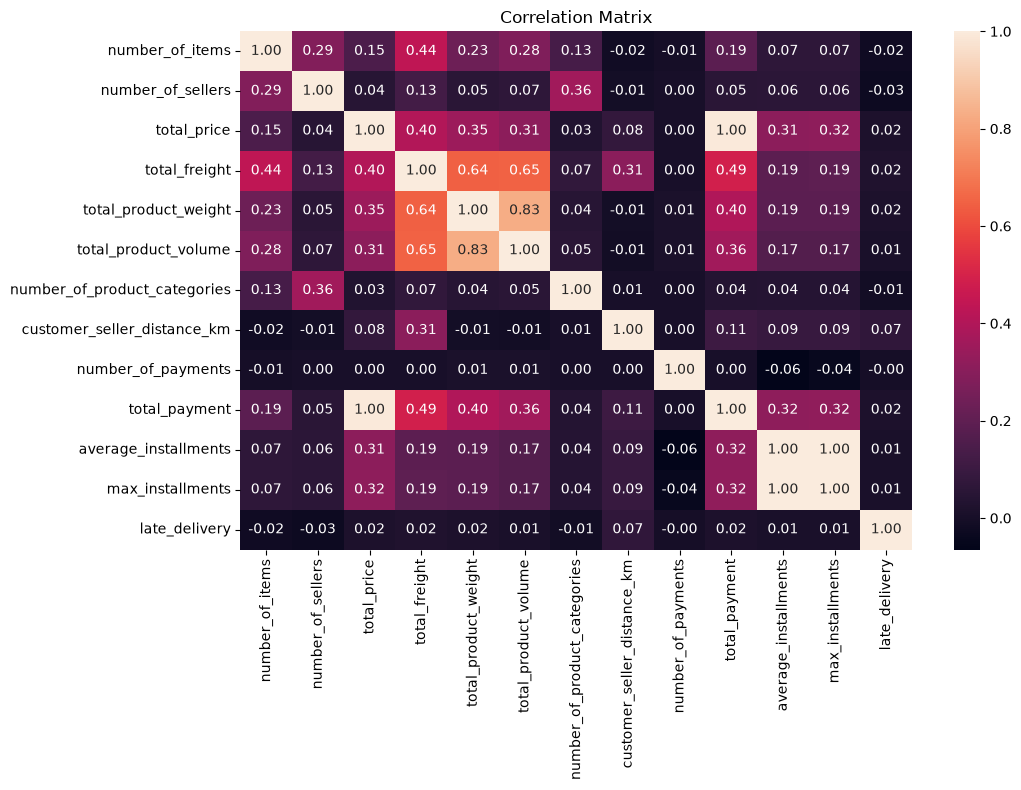

In [14]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    train[
        numerical_features + [target_column]
    ].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/correlation_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 10. Categorical Features

We examine categorical variables by checking their number of unique
values and their most frequent categories.

This is especially important for high-cardinality variables.

In [15]:
categorical_features = [
    "order_status",
    "customer_city",
    "customer_state",
    "main_payment_type"
]

categorical_cardinality = pd.DataFrame({
    "feature": categorical_features,
    "unique_values": [
        train[column].nunique(dropna=False)
        for column in categorical_features
    ]
})

categorical_cardinality

,feature,unique_values
0,order_status,1
1,customer_city,3692
2,customer_state,27
3,main_payment_type,4


In [16]:
for column in categorical_features:
    print(f"\n--- {column} ---")

    print(
        train[column]
        .value_counts(dropna=False)
        .head(15)
    )


--- order_status ---
order_status
delivered    67529
Name: count, dtype: int64

--- customer_city ---
customer_city
sao paulo                10630
rio de janeiro            4715
belo horizonte            1861
brasilia                  1415
curitiba                  1040
campinas                   990
porto alegre               936
salvador                   839
guarulhos                  790
sao bernardo do campo      604
niteroi                    575
santo andre                574
osasco                     500
santos                     498
sao jose dos campos        466
Name: count, dtype: int64

--- customer_state ---
customer_state
SP    28361
RJ     8664
MG     7948
RS     3734
PR     3450
SC     2487
BA     2274
DF     1423
ES     1401
GO     1368
PE     1124
CE      879
PA      670
MT      636
MA      514
Name: count, dtype: int64

--- main_payment_type ---
main_payment_type
credit_card    50896
boleto         13463
voucher         2135
debit_card      1035
Name: count, dtype

## 11. Check Rare Categories

Some categorical variables contain many categories with very few orders.

This is important when choosing the encoding method in Notebook 5.

In [17]:
rare_category_summary = []

for column in categorical_features:
    value_counts = train[column].value_counts(
        dropna=False
    )

    rare_categories = value_counts[
        value_counts < 10
    ]

    rare_category_summary.append({
        "feature": column,
        "rare_categories_less_than_10": len(rare_categories),
        "rows_in_rare_categories": rare_categories.sum(),
        "percentage_of_rows": (
            rare_categories.sum()
            / len(train)
            * 100
        )
    })

rare_category_summary = pd.DataFrame(
    rare_category_summary
)

rare_category_summary

,feature,rare_categories_less_than_10,rows_in_rare_categories,percentage_of_rows
0,order_status,0,0,0.000000
1,customer_city,2972,8046,11.914881
2,customer_state,0,0,0.000000
3,main_payment_type,0,0,0.000000


## 12. Late Delivery by Customer State

Customer state may capture geographic differences in delivery performance.

We compare the late-delivery rate across states and also keep the number
of orders in each state.

In [18]:
state_late_rate = (
    train.groupby("customer_state")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
    .sort_values(
        "late_rate",
        ascending=False
    )
)

state_late_rate["late_rate"] *= 100

state_late_rate

,order_count,late_rate
customer_state,,
AL,279,25.089606
MA,514,20.428016
SE,223,16.143498
CE,879,15.813424
PI,350,14.857143
BA,2274,14.204046
RJ,8664,13.388735
RR,30,13.333333
ES,1401,12.705211


In [19]:
state_late_rate_filtered = state_late_rate[
    state_late_rate["order_count"] >= 100
]

state_late_rate_filtered

,order_count,late_rate
customer_state,,
AL,279,25.089606
MA,514,20.428016
SE,223,16.143498
CE,879,15.813424
PI,350,14.857143
BA,2274,14.204046
RJ,8664,13.388735
ES,1401,12.705211
MS,480,12.291667


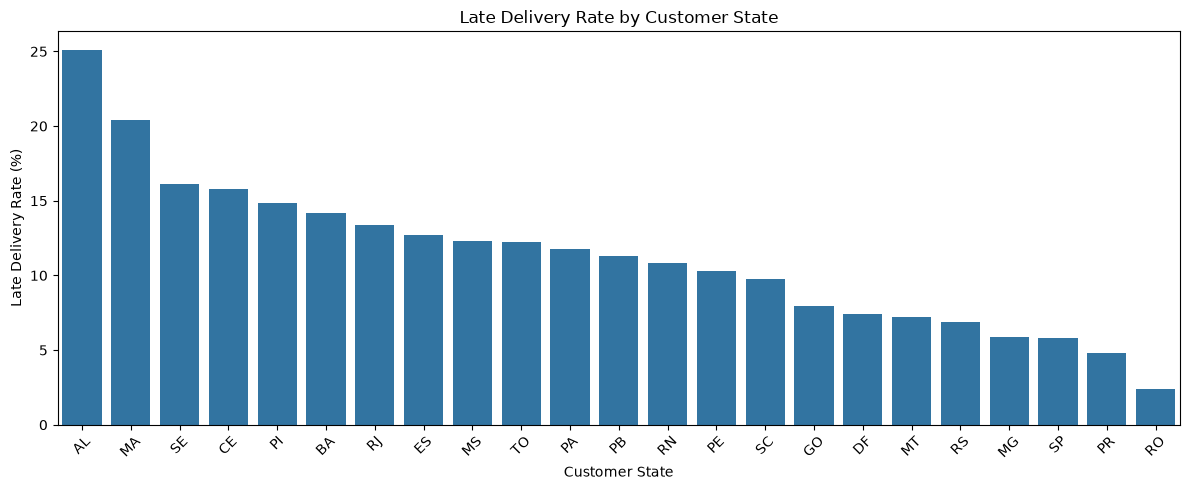

In [20]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=state_late_rate_filtered.reset_index(),
    x="customer_state",
    y="late_rate"
)

plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/late_rate_by_customer_state.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 13. Number of Sellers

An order can contain products from more than one seller.

We check whether the number of sellers is associated with late delivery.

In [21]:
seller_count_late_rate = (
    train.groupby("number_of_sellers")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
    .sort_index()
)

seller_count_late_rate["late_rate"] *= 100

seller_count_late_rate

,order_count,late_rate
number_of_sellers,,
1.0,66636,8.202773
2.0,856,1.401869
3.0,33,0.000000
4.0,3,0.000000
5.0,1,0.000000


## 14. Geographic Features

Two geographic features were created in Notebook 1:

- `customer_seller_distance_km`
- `customer_seller_same_state`

We check their relationship with late delivery.

The raw latitude and longitude columns are not used as model features.

In [22]:
distance_summary = (
    train.groupby("late_delivery")[
        "customer_seller_distance_km"
    ]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
)

distance_summary

,count,mean,median,min,max
late_delivery,,,,,
0,61759,588.878473,427.241879,0.0,5338.619482
1,5442,745.633255,518.645567,0.0,8677.911544


In [23]:
same_state_late_rate = (
    train.groupby("customer_seller_same_state")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
)

same_state_late_rate["late_rate"] *= 100

same_state_late_rate

,order_count,late_rate
customer_seller_same_state,,
False,43357,9.327214
True,24172,5.932484


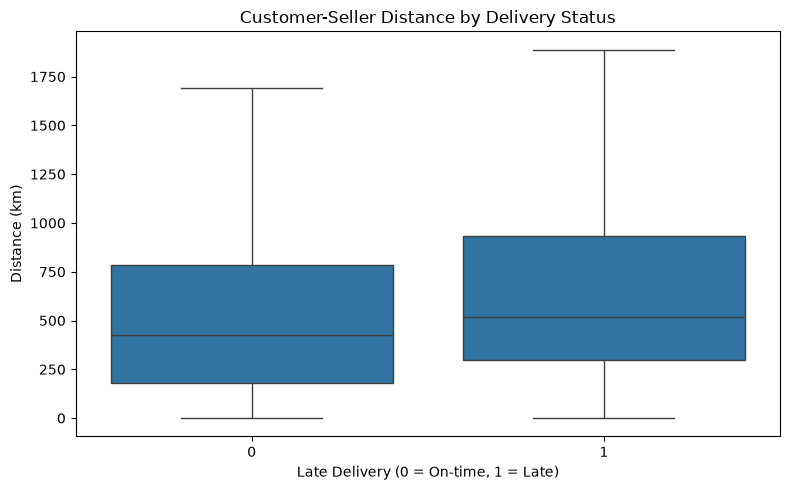

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="late_delivery",
    y="customer_seller_distance_km",
    showfliers=False
)

plt.title("Customer-Seller Distance by Delivery Status")
plt.xlabel("Late Delivery (0 = On-time, 1 = Late)")
plt.ylabel("Distance (km)")
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/customer_seller_distance_by_target.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 15. Product and Order Composition

We check whether physical product characteristics and order composition
are related to late delivery.

The main features are:

- Total product weight
- Total product volume
- Number of items
- Number of product categories

In [25]:
product_group_summary = (
    train.groupby("late_delivery")[
        [
            "number_of_items",
            "number_of_product_categories",
            "total_product_weight",
            "total_product_volume"
        ]
    ]
    .agg(
        ["mean", "median"]
    )
)

product_group_summary

number_of_items        number_of_product_categories         \
                         mean median                         mean median   
late_delivery                                                              
0                    1.143414    1.0                     0.994311    1.0   
1                    1.106061    1.0                     0.986674    1.0   

              total_product_weight        total_product_volume          
                              mean median                 mean  median  
late_delivery                                                           
0                      2359.146863  750.0         17205.276837  7200.0  
1                      2650.648777  825.0         18267.034319  7423.0

In [26]:
items_late_rate = (
    train.groupby("number_of_items")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
    .sort_index()
)

items_late_rate["late_rate"] *= 100

items_late_rate_filtered = items_late_rate[
    items_late_rate["order_count"] >= 100
]

items_late_rate_filtered

,order_count,late_rate
number_of_items,,
1.0,60869,8.309649
2.0,5102,6.507252
3.0,912,5.482456
4.0,338,4.733728
5.0,128,7.031250
6.0,140,9.285714


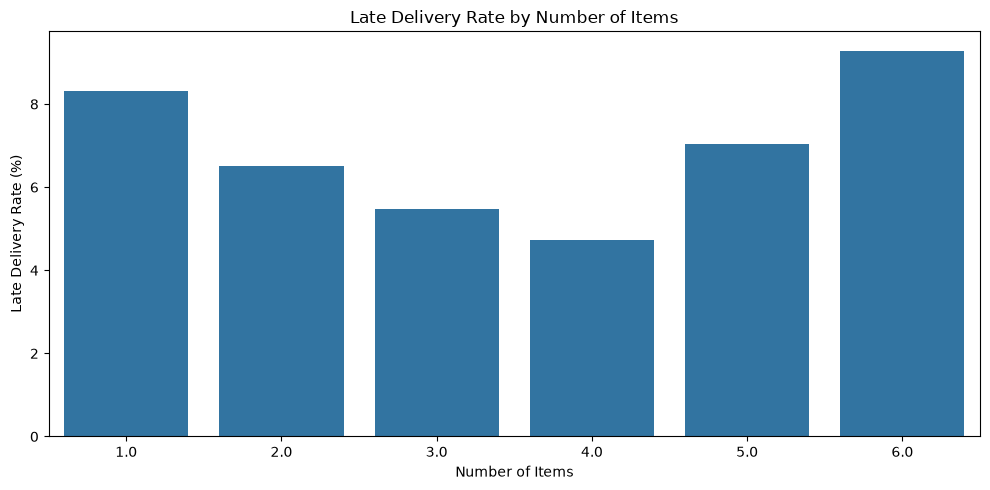

In [27]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=items_late_rate_filtered.reset_index(),
    x="number_of_items",
    y="late_rate"
)

plt.title("Late Delivery Rate by Number of Items")
plt.xlabel("Number of Items")
plt.ylabel("Late Delivery Rate (%)")
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/late_rate_by_number_of_items.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 16. Payment Features

We check whether payment-related variables differ between on-time
and late orders.

These variables are available by the time the order is placed.

In [28]:
payment_group_summary = (
    train.groupby("late_delivery")[
        [
            "number_of_payments",
            "total_payment",
            "average_installments",
            "max_installments"
        ]
    ]
    .mean()
)

payment_group_summary

,number_of_payments,total_payment,average_installments,max_installments
late_delivery,,,,
0,1.045076,159.481791,2.905322,2.921855
1,1.039978,173.501409,2.975610,2.992333


### Main payment type

We compare the late-delivery rate across the main payment types.

In [29]:
payment_type_late_rate = (
    train.groupby("main_payment_type")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
    .sort_values(
        "late_rate",
        ascending=False
    )
)

payment_type_late_rate["late_rate"] *= 100

payment_type_late_rate

,order_count,late_rate
main_payment_type,,
boleto,13463,9.039590
debit_card,1035,7.922705
credit_card,50896,7.896495
voucher,2135,7.494145


## 17. Estimated Delivery Time

The estimated delivery date is important because the target is defined
relative to it.

If the estimated date is available when the order is placed, the number
of estimated delivery days can be used as a prediction feature.

We calculate it here and examine its relationship with the target.

In [30]:
train["estimated_delivery_days"] = (
    train["order_estimated_delivery_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

train["estimated_delivery_days"].describe()

count    67529.000000
mean        23.765080
std          8.808377
min          2.008009
25%         18.348634
50%         23.243056
75%         28.408160
max        155.135463
Name: estimated_delivery_days, dtype: float64

In [31]:
estimated_delivery_summary = (
    train.groupby("late_delivery")[
        "estimated_delivery_days"
    ]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
)

estimated_delivery_summary

,count,mean,median,min,max
late_delivery,,,,,
0,62051,23.919399,23.305185,2.010451,155.135463
1,5478,22.017057,22.243079,2.008009,69.342373


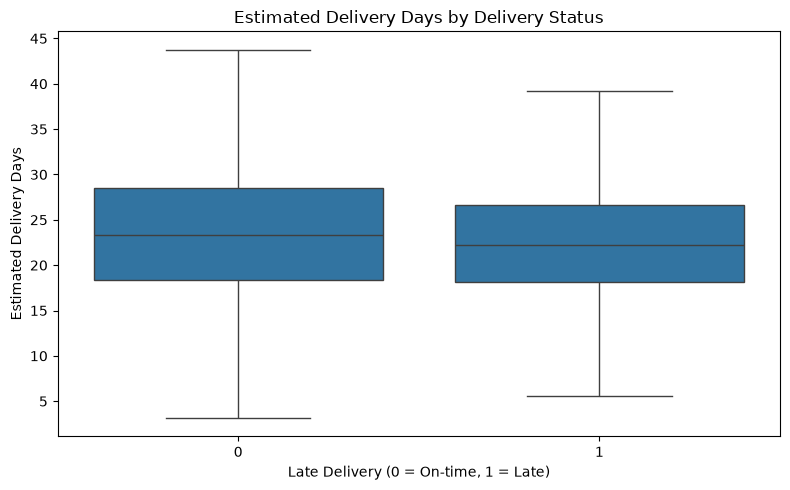

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="late_delivery",
    y="estimated_delivery_days",
    showfliers=False
)

plt.title("Estimated Delivery Days by Delivery Status")
plt.xlabel("Late Delivery (0 = On-time, 1 = Late)")
plt.ylabel("Estimated Delivery Days")
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/estimated_delivery_days_by_target.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 18. Date and Time Analysis

The purchase timestamp is available when the order is placed.

Temporary features are created to examine seasonality, weekdays,
purchase hours, and weekends.

In [33]:
train["purchase_year"] = (
    train["order_purchase_timestamp"].dt.year
)

train["purchase_month"] = (
    train["order_purchase_timestamp"].dt.month
)

train["purchase_dayofweek"] = (
    train["order_purchase_timestamp"].dt.dayofweek
)

train["purchase_hour"] = (
    train["order_purchase_timestamp"].dt.hour
)

train["is_weekend"] = (
    train["purchase_dayofweek"] >= 5
)

In [34]:
monthly_late_rate = (
    train.groupby("purchase_month")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
)

monthly_late_rate["late_rate"] *= 100

monthly_late_rate

,order_count,late_rate
purchase_month,,
1,5480,6.076642
2,5771,13.446543
3,6662,16.781747
4,6393,6.084780
5,7170,6.778243
6,6472,2.194067
7,7077,4.041260
8,7324,7.413981
9,2853,5.432878


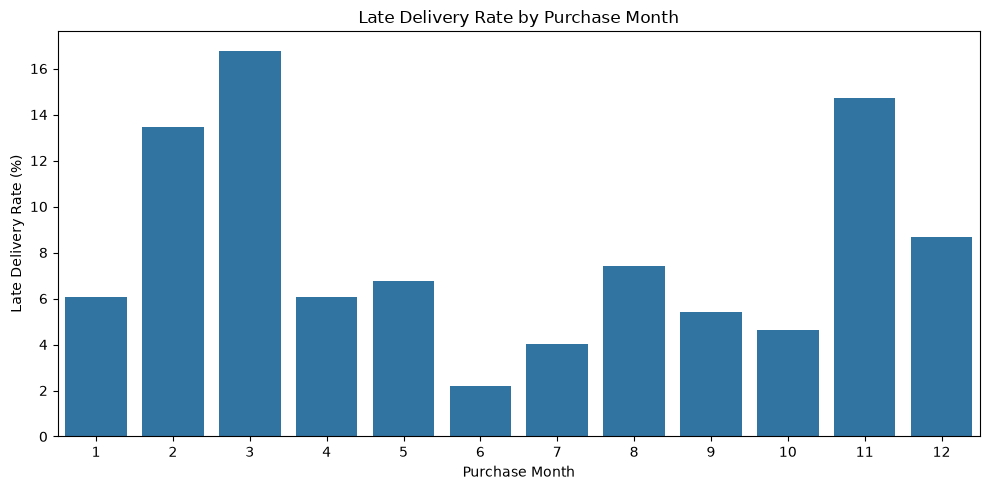

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_late_rate.reset_index(),
    x="purchase_month",
    y="late_rate"
)

plt.title("Late Delivery Rate by Purchase Month")
plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/late_rate_by_month.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [36]:
day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_late_rate = (
    train.groupby("purchase_dayofweek")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
    .reindex(range(7))
)

weekday_late_rate["late_rate"] *= 100

weekday_late_rate.index = day_names

weekday_late_rate

,order_count,late_rate
Monday,10988,8.955224
Tuesday,10862,8.423863
Wednesday,10558,7.795037
Thursday,9972,7.601284
Friday,9649,8.736657
Saturday,7391,7.455013
Sunday,8109,7.448514


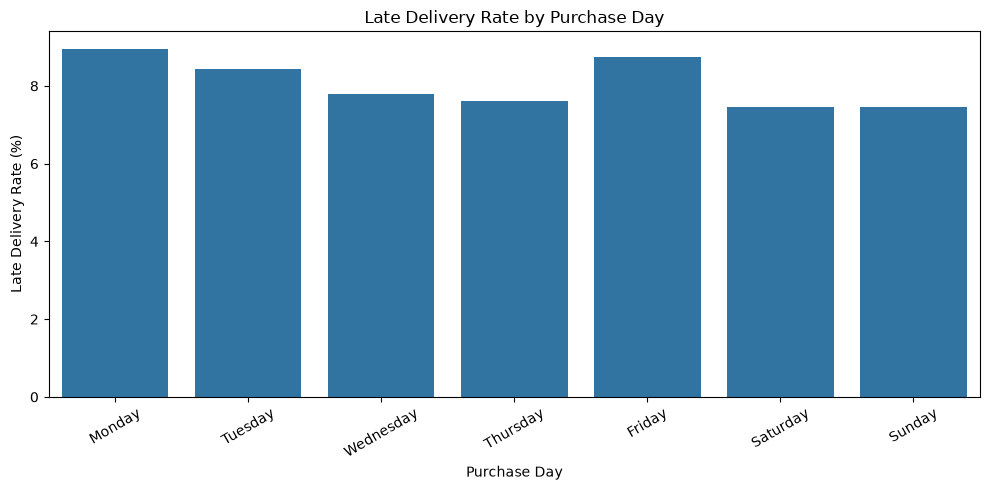

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_late_rate.index,
    y=weekday_late_rate["late_rate"].values
)

plt.title("Late Delivery Rate by Purchase Day")
plt.xlabel("Purchase Day")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/late_rate_by_weekday.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [38]:
hourly_late_rate = (
    train.groupby("purchase_hour")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
)

hourly_late_rate["late_rate"] *= 100

hourly_late_rate

,order_count,late_rate
purchase_hour,,
0,1647,9.168185
1,785,8.280255
2,347,6.916427
3,184,4.891304
4,139,3.597122
5,139,5.755396
6,324,8.641975
7,845,8.284024
8,2082,7.492795


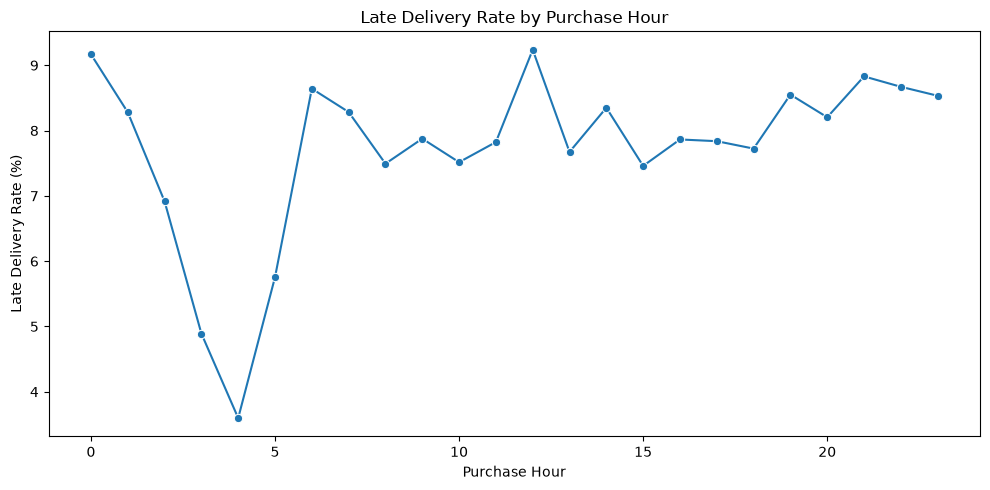

In [39]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_late_rate.reset_index(),
    x="purchase_hour",
    y="late_rate",
    marker="o"
)

plt.title("Late Delivery Rate by Purchase Hour")
plt.xlabel("Purchase Hour")
plt.ylabel("Late Delivery Rate (%)")
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/late_rate_by_hour.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 19. Weekend Effect

We check whether orders placed on weekends have a different
late-delivery rate.

In [40]:
weekend_late_rate = (
    train.groupby("is_weekend")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
)

weekend_late_rate["late_rate"] *= 100

weekend_late_rate.index = [
    "Weekday",
    "Weekend"
]

weekend_late_rate

,order_count,late_rate
Weekday,52029,8.308828
Weekend,15500,7.451613


## Day of Month

We check whether the day of the month when an order was placed is
associated with late delivery.

This may show differences between the beginning, middle, and end of
the month.

In [41]:
train["purchase_dayofmonth"] = (
    train["order_purchase_timestamp"].dt.day
)

day_of_month_late_rate = (
    train.groupby("purchase_dayofmonth")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
)

day_of_month_late_rate["late_rate"] *= 100

day_of_month_late_rate

,order_count,late_rate
purchase_dayofmonth,,
1,2108,8.206831
2,2186,8.279963
3,2238,6.970509
4,2349,7.151980
5,2287,7.214692
6,2348,8.475298
7,2222,8.235824
8,2277,7.378129
9,2204,7.214156


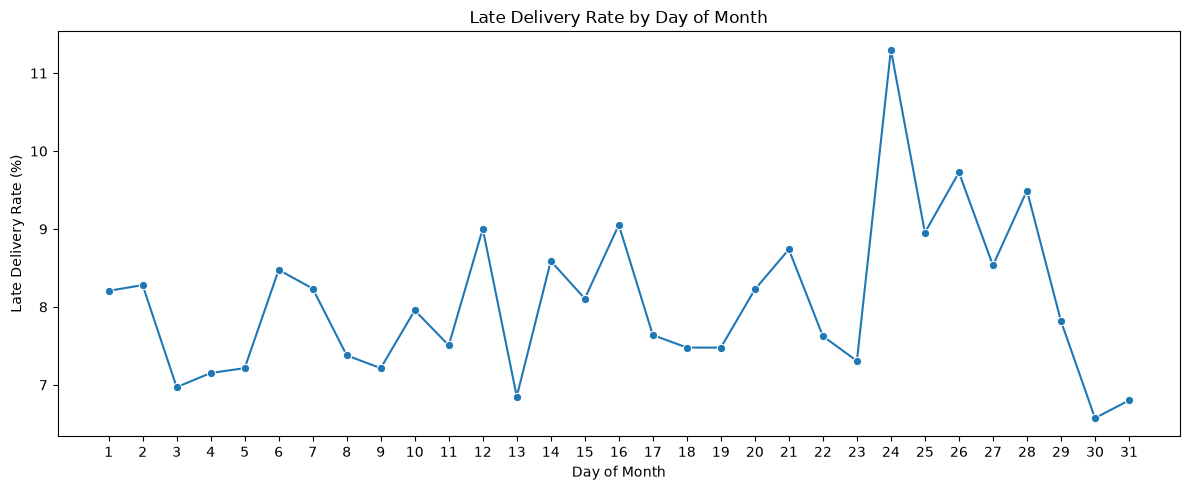

In [42]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=day_of_month_late_rate.reset_index(),
    x="purchase_dayofmonth",
    y="late_rate",
    marker="o"
)

plt.title("Late Delivery Rate by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(range(1, 32))
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/late_rate_by_day_of_month.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [43]:
train["purchase_period"] = pd.cut(
    train["purchase_dayofmonth"],
    bins=[0, 10, 20, 31],
    labels=[
        "Beginning",
        "Middle",
        "End"
    ]
)

day_period_late_rate = (
    train.groupby("purchase_period", observed=True)["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
)

day_period_late_rate["late_rate"] *= 100

day_period_late_rate

,order_count,late_rate
purchase_period,,
Beginning,22343,7.702636
Middle,22720,7.997359
End,22466,8.635271


In [44]:
print("=" * 70)
print("DAY OF MONTH ANALYSIS")
print("=" * 70)

# Late-delivery rate for each day of the month
day_of_month_late_rate = (
    train.groupby("purchase_dayofmonth")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
)

day_of_month_late_rate["late_rate"] *= 100

print("\n1. Late delivery rate by day of month")
display(
    day_of_month_late_rate.round(2)
)

print("\n2. Days with the highest late-delivery rate")
display(
    day_of_month_late_rate
    .sort_values("late_rate", ascending=False)
    .head(10)
    .round(2)
)

print("\n3. Days with the lowest late-delivery rate")
display(
    day_of_month_late_rate
    .sort_values("late_rate", ascending=True)
    .head(10)
    .round(2)
)

# Compare the beginning, middle, and end of the month
train["purchase_period"] = pd.cut(
    train["purchase_dayofmonth"],
    bins=[0, 10, 20, 31],
    labels=["Beginning", "Middle", "End"]
)

day_period_late_rate = (
    train.groupby("purchase_period", observed=True)["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
)

day_period_late_rate["late_rate"] *= 100

print("\n4. Late delivery rate by month period")
display(
    day_period_late_rate.round(2)
)

# Compare the overall range of daily late-delivery rates
print("\n5. Daily rate range")

min_day = day_of_month_late_rate["late_rate"].idxmin()
max_day = day_of_month_late_rate["late_rate"].idxmax()

min_rate = day_of_month_late_rate.loc[min_day, "late_rate"]
max_rate = day_of_month_late_rate.loc[max_day, "late_rate"]

print(
    f"Lowest: Day {min_day} -> {min_rate:.2f}%"
)

print(
    f"Highest: Day {max_day} -> {max_rate:.2f}%"
)

print(
    f"Difference: {max_rate - min_rate:.2f} percentage points"
)

DAY OF MONTH ANALYSIS

1. Late delivery rate by day of month


,order_count,late_rate
purchase_dayofmonth,,
1,2108,8.21
2,2186,8.28
3,2238,6.97
4,2349,7.15
5,2287,7.21
6,2348,8.48
7,2222,8.24
8,2277,7.38
9,2204,7.21



2. Days with the highest late-delivery rate


,order_count,late_rate
purchase_dayofmonth,,
24,2699,11.30
26,2262,9.73
28,2033,9.49
16,2408,9.05
12,2166,9.00
25,2256,8.95
21,2140,8.74
14,2282,8.59
27,2133,8.53



3. Days with the lowest late-delivery rate


,order_count,late_rate
purchase_dayofmonth,,
30,1719,6.57
31,1147,6.80
13,2219,6.85
3,2238,6.97
4,2349,7.15
9,2204,7.21
5,2287,7.21
23,2135,7.31
8,2277,7.38



4. Late delivery rate by month period


,order_count,late_rate
purchase_period,,
Beginning,22343,7.70
Middle,22720,8.00
End,22466,8.64



5. Daily rate range
Lowest: Day 30 -> 6.57%
Highest: Day 24 -> 11.30%
Difference: 4.73 percentage points


## 20. Holiday Effect

The dataset contains Brazilian orders, so we check whether orders
placed on Brazilian holidays have a different late-delivery rate.

This is an exploratory feature and will only be kept if it provides
useful information.

In [45]:
years = (
    train["order_purchase_timestamp"]
    .dt.year
    .dropna()
    .unique()
)

years = [
    int(year)
    for year in years
]

brazil_holidays = holidays.Brazil(
    years=years
)

train["is_holiday"] = (
    train["order_purchase_timestamp"]
    .dt.date
    .isin(brazil_holidays)
)

holiday_late_rate = (
    train.groupby("is_holiday")["late_delivery"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
)

holiday_late_rate["late_rate"] *= 100

holiday_late_rate.index = [
    "Non-holiday",
    "Holiday"
]

holiday_late_rate

,order_count,late_rate
Non-holiday,66475,8.138398
Holiday,1054,6.451613


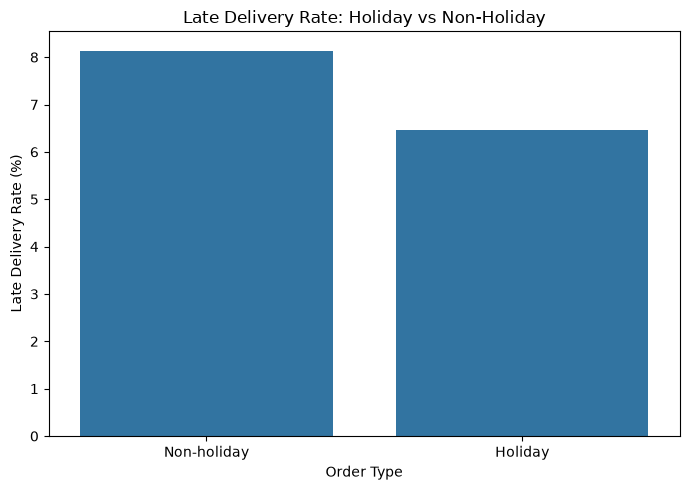

In [46]:
plot_data = holiday_late_rate.reset_index()

# Rename the columns so the plot uses clear names
plot_data.columns = [
    "order_type",
    "order_count",
    "late_rate"
]

plt.figure(figsize=(7, 5))

sns.barplot(
    data=plot_data,
    x="order_type",
    y="late_rate"
)

plt.title("Late Delivery Rate: Holiday vs Non-Holiday")
plt.xlabel("Order Type")
plt.ylabel("Late Delivery Rate (%)")
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/late_rate_holiday_vs_nonholiday.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 21. Delivery-Stage Analysis

Delivery timestamps can help us understand what happened after the
order was placed.

These variables are used only for analysis and will not be used as
model predictors because they are not available at prediction time.

In [47]:
train["delivery_duration_days"] = (
    train["order_delivered_customer_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

delivery_duration_summary = (
    train.groupby("late_delivery")[
        "delivery_duration_days"
    ]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

delivery_duration_summary

,count,mean,median,std,min,max
late_delivery,,,,,,
0,62051,10.874114,9.719907,6.177043,0.533414,63.735324
1,5478,31.589427,29.187147,17.518335,2.129537,209.628611


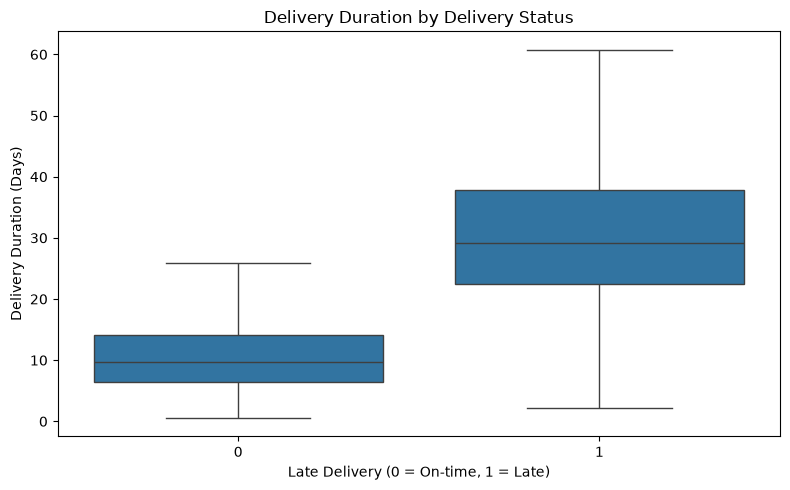

In [48]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="late_delivery",
    y="delivery_duration_days",
    showfliers=False
)

plt.title("Delivery Duration by Delivery Status")
plt.xlabel("Late Delivery (0 = On-time, 1 = Late)")
plt.ylabel("Delivery Duration (Days)")
plt.tight_layout()

plt.savefig(
    "../artifacts/random_split/eda1/delivery_duration_by_target.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 22. Delivery Stage Timing

We also inspect the time between approval, carrier handoff, and customer
delivery.

These variables help explain the problem, but they are future information
for an order-time prediction model.

In [49]:
train["carrier_handling_days"] = (
    train["order_delivered_carrier_date"]
    - train["order_approved_at"]
).dt.total_seconds() / (24 * 60 * 60)

train["carrier_to_customer_days"] = (
    train["order_delivered_customer_date"]
    - train["order_delivered_carrier_date"]
).dt.total_seconds() / (24 * 60 * 60)

stage_summary = (
    train.groupby("late_delivery")[
        [
            "carrier_handling_days",
            "carrier_to_customer_days"
        ]
    ]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
)

stage_summary

carrier_handling_days                                            \
                              count      mean    median       min         max   
late_delivery                                                                   
0                             62040  2.571057  1.742922 -9.341262   47.500880   
1                              5478  5.235967  3.005804 -9.045926  107.053218   

              carrier_to_customer_days                                   \
                                 count       mean     median        min   
late_delivery                                                             
0                                62051   7.882437   6.929803 -16.096169   
1                                 5478  25.836809  24.026123   0.000012   

                           
                      max  
late_delivery              
0               48.969618  
1              195.033947

In [50]:
negative_stage_values = pd.DataFrame({
    "carrier_handling_negative": [
        (train["carrier_handling_days"] < 0).sum()
    ],
    "carrier_to_customer_negative": [
        (train["carrier_to_customer_days"] < 0).sum()
    ]
})

negative_stage_values

,carrier_handling_negative,carrier_to_customer_negative
0,920,17


## 23. Customer Geography Details

We examine the cardinality of customer city and ZIP-code prefix.

`customer_city` has many categories, so it may require a special encoding
strategy.

The ZIP-code prefix is treated as a geographic identifier rather than
a continuous numerical variable.

In [51]:
geography_summary = pd.DataFrame({
    "feature": [
        "customer_state",
        "customer_city",
        "customer_zip_code_prefix"
    ],
    "unique_values": [
        train["customer_state"].nunique(dropna=False),
        train["customer_city"].nunique(dropna=False),
        train["customer_zip_code_prefix"].nunique(dropna=False)
    ]
})

geography_summary

,feature,unique_values
0,customer_state,27
1,customer_city,3692
2,customer_zip_code_prefix,13697


## 24. Compare Geographic Features

Distance and same-state status describe the relationship between
the customer and seller.

We check both because they may capture different information.

In [52]:
geographic_feature_summary = pd.DataFrame({
    "feature": [
        "customer_seller_distance_km",
        "customer_seller_same_state"
    ],
    "missing_count": [
        train["customer_seller_distance_km"].isna().sum(),
        train["customer_seller_same_state"].isna().sum()
    ],
    "missing_percentage": [
        train["customer_seller_distance_km"].isna().mean() * 100,
        train["customer_seller_same_state"].isna().mean() * 100
    ]
})

geographic_feature_summary

,feature,missing_count,missing_percentage
0,customer_seller_distance_km,328,0.485717
1,customer_seller_same_state,0,0.000000


## 25. Feature Candidate Decisions

The EDA is used to identify candidate features and variables that should
be excluded from modeling.

These are initial decisions and will be finalized together with the
preprocessing and model results in Notebook 5.

In [53]:
feature_decision = pd.DataFrame({
    "feature": [
        "number_of_items",
        "number_of_sellers",
        "total_price",
        "total_freight",
        "total_product_weight",
        "total_product_volume",
        "number_of_product_categories",
        
        "customer_seller_distance_km",
        "customer_seller_same_state",
        
        "number_of_payments",
        "total_payment",
        "average_installments",
        "max_installments",
        "main_payment_type",
        
        "customer_state",
        "customer_city",
        "customer_zip_code_prefix",
        
        "customer_unique_id",
        
        "order_purchase_timestamp",
        "purchase_year",
        "purchase_month",
        "purchase_dayofweek",
        "purchase_hour",
        "purchase_dayofmonth",
        "is_weekend",
        "is_holiday",
        
        "order_estimated_delivery_date",
        "estimated_delivery_days",
        
        "order_status",
        "order_id",
        "customer_id",
        
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "delivery_delay_days"
    ],
    "decision": [
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        
        "Candidate",
        "Candidate",
        
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate - highly similar to max_installments",
        "Candidate",
        
        "Candidate - low cardinality",
        "Candidate - high cardinality",
        "Candidate - high cardinality geographic feature",
        
        "Historical feature source - not used raw",
        
        "Derive time features",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        "Candidate",
        
        "Source for estimated_delivery_days",
        "Candidate if available at prediction time",
        
        "Remove - constant",
        "Remove - ID",
        "Remove - ID",
        
        "Remove - future information",
        "Remove - future information",
        "Remove - future information",
        "Remove - target-derived information"
    ]
})

feature_decision

,feature,decision
0,number_of_items,Candidate
1,number_of_sellers,Candidate
2,total_price,Candidate
3,total_freight,Candidate
4,total_product_weight,Candidate
5,total_product_volume,Candidate
6,number_of_product_categories,Candidate
7,customer_seller_distance_km,Candidate
8,customer_seller_same_state,Candidate
9,number_of_payments,Candidate


## 26. Main EDA Findings

The main findings are summarized below.

These findings will guide the feature engineering and preprocessing
decisions in Notebook 5.

In [54]:
target_distribution = (
    train["late_delivery"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

findings = {
    "dataset_shape": train.shape,

    "target_distribution_percent": (
        target_distribution.to_dict()
    ),

    "numerical_features": numerical_features,

    "categorical_features": categorical_features,

    "high_cardinality_features": [
        "customer_city",
        "customer_zip_code_prefix"
    ],

    "geographic_features": [
        "customer_state",
        "customer_seller_distance_km",
        "customer_seller_same_state"
    ],

    "product_features": [
        "number_of_items",
        "number_of_sellers",
        "total_product_weight",
        "total_product_volume",
        "number_of_product_categories"
    ],

    "payment_features": [
        "number_of_payments",
        "total_payment",
        "average_installments",
        "max_installments",
        "main_payment_type"
    ],

    "purchase_time_features": [
        "purchase_year",
        "purchase_month",
        "purchase_dayofweek",
        "purchase_hour",
        "purchase_dayofmonth",
        "is_weekend",
        "is_holiday"
    ],

    "estimated_delivery_feature": [
        "estimated_delivery_days"
    ],

    "future_information_columns": [
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "delivery_delay_days"
    ],

    "ids_to_remove": [
        "order_id",
        "customer_id"
    ],

    "historical_feature_sources": [
        "customer_unique_id"
    ]
}

findings

{'dataset_shape': (67529, 40),
 'target_distribution_percent': {0: 91.89, 1: 8.11},
 'numerical_features': ['number_of_items',
  'number_of_sellers',
  'total_price',
  'total_freight',
  'total_product_weight',
  'total_product_volume',
  'number_of_product_categories',
  'customer_seller_distance_km',
  'number_of_payments',
  'total_payment',
  'average_installments',
  'max_installments'],
 'categorical_features': ['order_status',
  'customer_city',
  'customer_state',
  'main_payment_type'],
 'high_cardinality_features': ['customer_city', 'customer_zip_code_prefix'],
 'geographic_features': ['customer_state',
  'customer_seller_distance_km',
  'customer_seller_same_state'],
 'product_features': ['number_of_items',
  'number_of_sellers',
  'total_product_weight',
  'total_product_volume',
  'number_of_product_categories'],
 'payment_features': ['number_of_payments',
  'total_payment',
  'average_installments',
  'max_installments',
  'main_payment_type'],
 'purchase_time_features':

## 27. Save the EDA Results

The charts, feature decisions, and summary are saved as artifacts.

These files can be reviewed later without rerunning the full EDA.

In [55]:
feature_decision.to_csv(
    "../artifacts/random_split/eda1/feature_decisions.csv",
    index=False
)

findings_text = f"""
Notebook 4 — EDA Findings

Dataset shape:
{train.shape}

Target distribution:
{target_distribution.to_string()}

Numerical features:
{numerical_features}

Categorical features:
{categorical_features}

Geographic features:
customer_state
customer_seller_distance_km
customer_seller_same_state

Product features:
number_of_items
number_of_sellers
total_product_weight
total_product_volume
number_of_product_categories

Payment features:
number_of_payments
total_payment
average_installments
max_installments
main_payment_type

Purchase-time features:
purchase_year
purchase_month
purchase_dayofweek
purchase_hour
purchase_dayofmonth
is_weekend
is_holiday

Estimated delivery feature:
estimated_delivery_days

High-cardinality features:
customer_city
customer_zip_code_prefix

Future-information variables excluded from modeling:
order_approved_at
order_delivered_carrier_date
order_delivered_customer_date
delivery_delay_days

IDs excluded from modeling:
order_id
customer_id

customer_unique_id:
Used as a possible source for historical features,
but not used as a raw model feature.

Potential geographic intermediate variables:
customer_lat
customer_lng
seller_lat
seller_lng

These coordinates are used only to derive
customer_seller_distance_km and are not used directly
as model features.

Main findings:
- The target is imbalanced, with late deliveries representing about 8.11% of the training data.
- Customer-seller distance is higher for late orders than for on-time orders.
- Orders where the customer and seller are in different states have a higher late-delivery rate.
- Customer state shows clear differences in late-delivery rates.
- Customer city has high cardinality and requires careful encoding.
- Product weight, product volume, price, freight, payment, and order composition remain candidate features.
- Purchase month shows clear differences in late-delivery rates.
- Purchase day, weekday, hour, weekend, and holiday effects are weaker and will be tested as candidate features.
- Estimated delivery days may be useful if the estimated delivery date is available at prediction time.
- Delivery-stage variables are useful for analysis but cannot be used as model predictors.
- Potential outliers were identified but were not removed automatically.
"""

with open(
    "../artifacts/random_split/eda1/findings_summary.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(findings_text)

print("EDA findings saved successfully.")

EDA findings saved successfully.


In [56]:
print("EDA artifacts:")

for file_name in sorted(
    os.listdir("../artifacts/random_split/eda1")
):
    print("-", file_name)

print(
    "\nFindings summary exists:",
    os.path.exists(
        "../artifacts/random_split/eda1/findings_summary.txt"
    )
)

print(
    "Feature decisions exists:",
    os.path.exists(
        "../artifacts/random_split/eda1/feature_decisions.csv"
    )
)

EDA artifacts:
- correlation_matrix.png
- customer_seller_distance_by_target.png
- delivery_duration_by_target.png
- distribution_average_installments.png
- distribution_customer_seller_distance_km.png
- distribution_max_installments.png
- distribution_number_of_items.png
- distribution_number_of_payments.png
- distribution_number_of_product_categories.png
- distribution_number_of_sellers.png
- distribution_total_freight.png
- distribution_total_payment.png
- distribution_total_price.png
- distribution_total_product_volume.png
- distribution_total_product_weight.png
- estimated_delivery_days_by_target.png
- feature_decisions.csv
- findings_summary.txt
- late_rate_by_customer_state.png
- late_rate_by_day_of_month.png
- late_rate_by_hour.png
- late_rate_by_month.png
- late_rate_by_number_of_items.png
- late_rate_by_weekday.png
- late_rate_holiday_vs_nonholiday.png
- numerical_boxplots.png

Findings summary exists: True
Feature decisions exists: True


## Final Summary

In this notebook, the training data was explored to understand the target distribution and the relationships between the available features and late deliveries.

The analysis showed that geographic and time-related variables were among the most informative factors. Customer-seller distance, same-state delivery, customer state, purchase time, and estimated delivery duration showed useful patterns related to late deliveries.

The EDA results were used to guide the feature selection and engineering decisions in Notebook 5.